In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, 
    precision_score, recall_score
)

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_lr_tuning, run_catboost_tuning, run_lgbm_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate

warnings.filterwarnings("ignore")

/Users/denismatveev/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Датасет [Jungle](https://www.openml.org/search?type=data&status=active&id=41027)

In [2]:
dataset_id = 41027
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lr = model_lr.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lr.predict_proba(X_test), multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr, average="macro"))

[I 2025-04-10 16:36:56,109] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-10 16:36:56,158] Trial 0 finished with value: 0.8039652077320941 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 0 with value: 0.8039652077320941.
[I 2025-04-10 16:36:56,240] Trial 1 finished with value: 0.8039652077320941 and parameters: {'penalty': 'l2', 'C': 0.001}. Best is trial 0 with value: 0.8039652077320941.
[I 2025-04-10 16:36:56,303] Trial 2 finished with value: 0.8034414558903292 and parameters: {'penalty': 'l2', 'C': 1}. Best is trial 0 with value: 0.8039652077320941.
[I 2025-04-10 16:36:56,352] Trial 3 finished with value: 0.8034414558903292 and parameters: {'penalty': 'l2', 'C': 1}. Best is trial 0 with value: 0.8039652077320941.
[I 2025-04-10 16:36:56,401] Trial 4 finished with value: 0.8034527808192338 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 0 with value: 0.8039652077320941.
[I 2025-04-10 16:36:56,448] Trial 5 finished with val

ROC-AUC = 0.8148
F1 = 0.4849
Accuracy = 0.6847
Precision = 0.5723
Recall = 0.5024


In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_cb = model_cb.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_cb.predict_proba(X_test), multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr, average="macro"))

[I 2025-04-10 16:36:57,273] A new study created in memory with name: catboost_optimization
[I 2025-04-10 16:37:00,745] Trial 0 finished with value: 0.9755269692743941 and parameters: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 0.01}. Best is trial 0 with value: 0.9755269692743941.
[I 2025-04-10 16:37:05,036] Trial 1 finished with value: 0.9695758377988507 and parameters: {'depth': 8, 'learning_rate': 0.01, 'l2_leaf_reg': 6.0}. Best is trial 0 with value: 0.9755269692743941.
[I 2025-04-10 16:37:08,600] Trial 2 finished with value: 0.9737962295641079 and parameters: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 0.01}. Best is trial 0 with value: 0.9755269692743941.
[I 2025-04-10 16:37:14,142] Trial 3 finished with value: 0.9729435789314834 and parameters: {'depth': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 0.1}. Best is trial 0 with value: 0.9755269692743941.
[I 2025-04-10 16:37:17,517] Trial 4 finished with value: 0.9754430728996738 and parameters: {'depth': 6, 'learning_rate

ROC-AUC = 0.9769
F1 = 0.4849
Accuracy = 0.6847
Precision = 0.5723
Recall = 0.5024


In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer, multi=True)
y_pred_lgbm = model_lgbm.predict(X_test)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, model_lgbm.predict_proba(X_test), multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred_lr, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred_lr))
print("Precision = %.4f" % precision_score(y_test, y_pred_lr, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred_lr, average="macro"))

[I 2025-04-10 16:38:10,155] A new study created in memory with name: lgdm_optimization
[I 2025-04-10 16:38:11,292] Trial 0 finished with value: 0.9507874805049831 and parameters: {'num_leaves': 4, 'reg_alpha': 1e-08, 'reg_lambda': 0.001, 'learning_rate': 0.03}. Best is trial 0 with value: 0.9507874805049831.
[I 2025-04-10 16:38:22,975] Trial 1 finished with value: 0.9774903573643211 and parameters: {'num_leaves': 128, 'reg_alpha': 1e-06, 'reg_lambda': 1e-08, 'learning_rate': 0.03}. Best is trial 1 with value: 0.9774903573643211.
[I 2025-04-10 16:39:34,248] Trial 2 finished with value: 0.9707617943229762 and parameters: {'num_leaves': 2048, 'reg_alpha': 1e-07, 'reg_lambda': 1.0, 'learning_rate': 0.03}. Best is trial 1 with value: 0.9774903573643211.
[I 2025-04-10 16:40:47,928] Trial 3 finished with value: 0.9722842179923842 and parameters: {'num_leaves': 4096, 'reg_alpha': 0.0001, 'reg_lambda': 0.1, 'learning_rate': 0.01}. Best is trial 1 with value: 0.9774903573643211.
[I 2025-04-10 16

ROC-AUC = 0.9814
F1 = 0.4849
Accuracy = 0.6847
Precision = 0.5723
Recall = 0.5024


In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


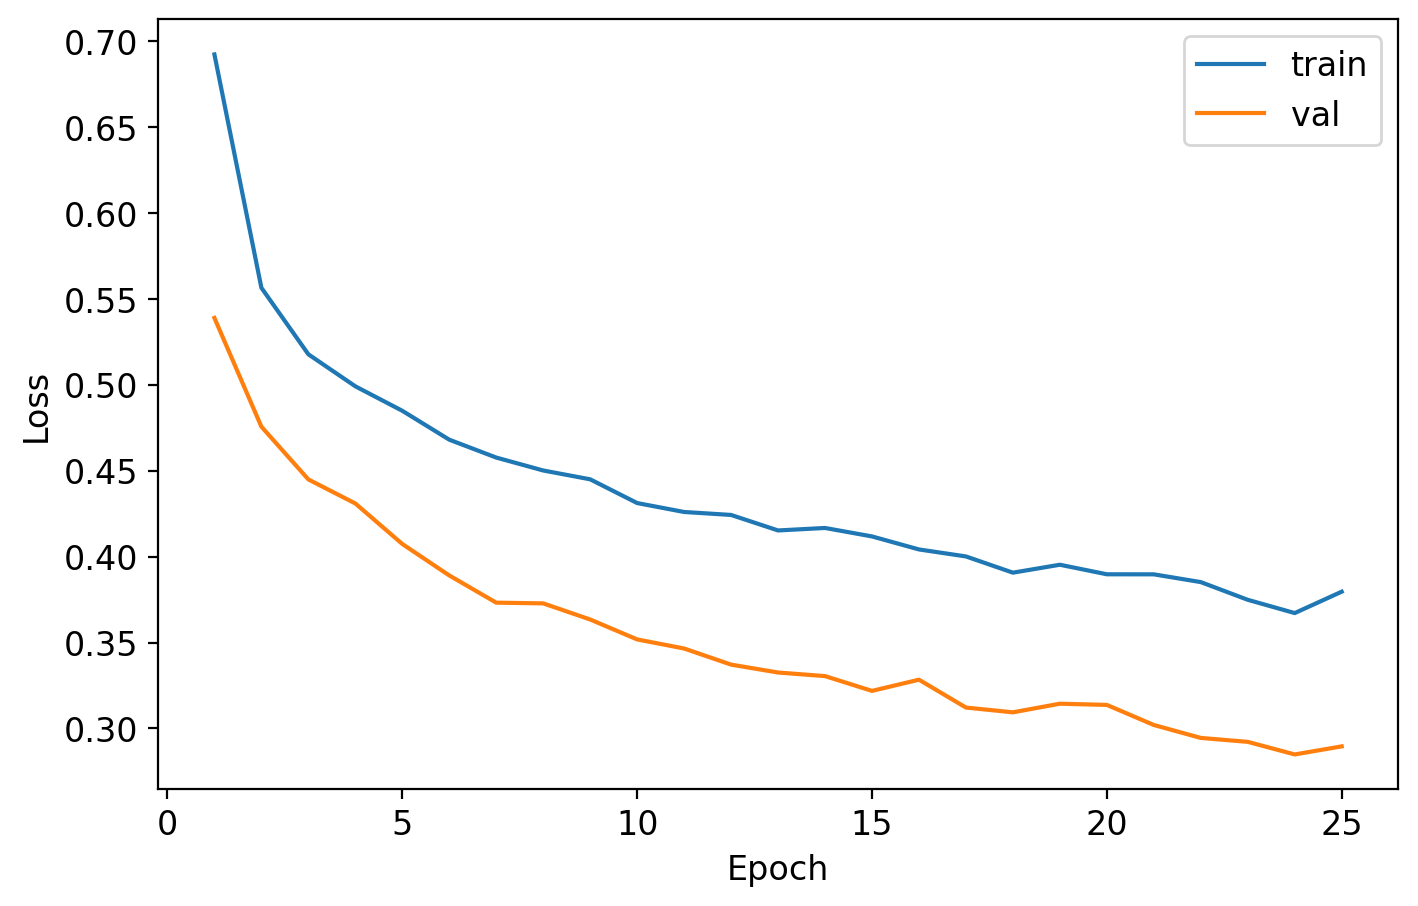

Epoch 25: train loss = 0.3796; valid loss = 0.2896


In [11]:
net = TABMLP(len(numerical_features), emb_dims, num_classes=len(np.unique(y_train))).to(device)
optimizer = optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 25, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device, multi=True)
print("ROC-AUC = %.4f" % roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"))
print("F1 = %.4f" % f1_score(y_test, y_pred, average="macro"))
print("Accuracy = %.4f" % accuracy_score(y_test, y_pred))
print("Precision = %.4f" % precision_score(y_test, y_pred, average="macro"))
print("Recall = %.4f" % recall_score(y_test, y_pred, average="macro"))

ROC-AUC = 0.9713
F1 = 0.8248
Accuracy = 0.8610
Precision = 0.8320
Recall = 0.8184
